# Статьи:

ACF и PACF - https://www.baeldung.com/cs/acf-pacf-plots-arma-modeling

# Загрузка библиотек

In [ ]:
import pandas as pd
import numpy as np
import tqdm
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from math import sqrt
import statsmodels
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle
import warnings


warnings.filterwarnings("ignore")

# Функции для анализа временных рядов

In [254]:
def test_stationarity(timeseries):
    p_value = adfuller(timeseries, autolag='AIC')[1]
    print(f"По тесту Дикки-Фуллера временной ряд стационарен: {p_value < 0.05}")

Данная функция выполняет тест Дики-Фуллера (Dickey-Fuller Test) — статистический тест, который проверяет стационарность временного ряда. Стационарность означает, что свойства ряда (среднее, дисперсия, автокорреляция) не меняются со временем. Это важное условие для многих моделей временных рядов (ARIMA, SARIMA и др.). p-value < 0.05 => ряд стационарный, иначе - нестационарный.

In [252]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)
        
        plt.tight_layout()
    plt.show()
    return

Функция tsplot() — это комплексный инструмент для визуального и статистического анализа временных рядов, который объединяет:

Тест на стационарность (Dickey-Fuller).

График исходного ряда.

Автокорреляционную (ACF) и частичную автокорреляционную (PACF) функции.

Q-Q plot для проверки нормальности распределения.

Этот метод полезен для предварительного анализа временных рядов перед построением моделей (ARIMA, SARIMA, регрессионных и др.).

# Загрузка временного ряда

In [248]:
series = pd.read_csv("AirPassengers.csv", index_col=0)["#Passengers"]

series

Month
1949-01    112
1949-02    118
1949-03    132
1949-04    129
1949-05    121
          ... 
1960-08    606
1960-09    508
1960-10    461
1960-11    390
1960-12    432
Name: #Passengers, Length: 144, dtype: int64

По тесту Дикки-Фуллера временной ряд стационарен: False


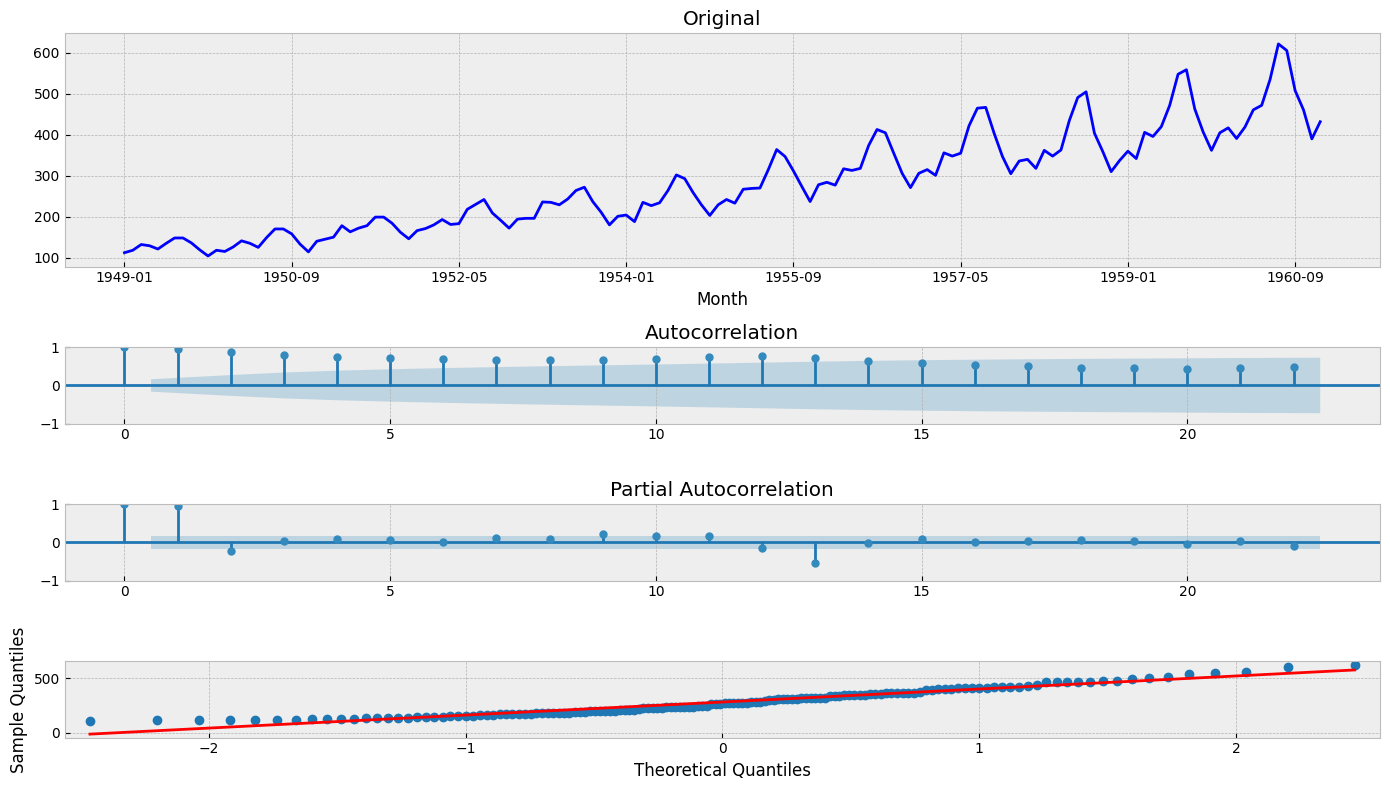

In [255]:
tsplot(series)

Для ARIMA нужно определить 3 параметра: 
* p - порядок авторегрессии (AR), то есть текущее значение t зависит от значения t-p. Определяется через график Partial Autocorrelation (PACF).
* q - порядок скользящего среднего (MA), то есть как текущее значение t зависит от ошибок значений от t-1 до t-q. Определяется через график Autocorrelation (ACF).
* d - порядок дифференцирования (кол-во раз), то есть через сколько раз временной ряд избавляется от тренда и немного сезонности.

По тесту Дикки-Фуллера временной ряд стационарен: False


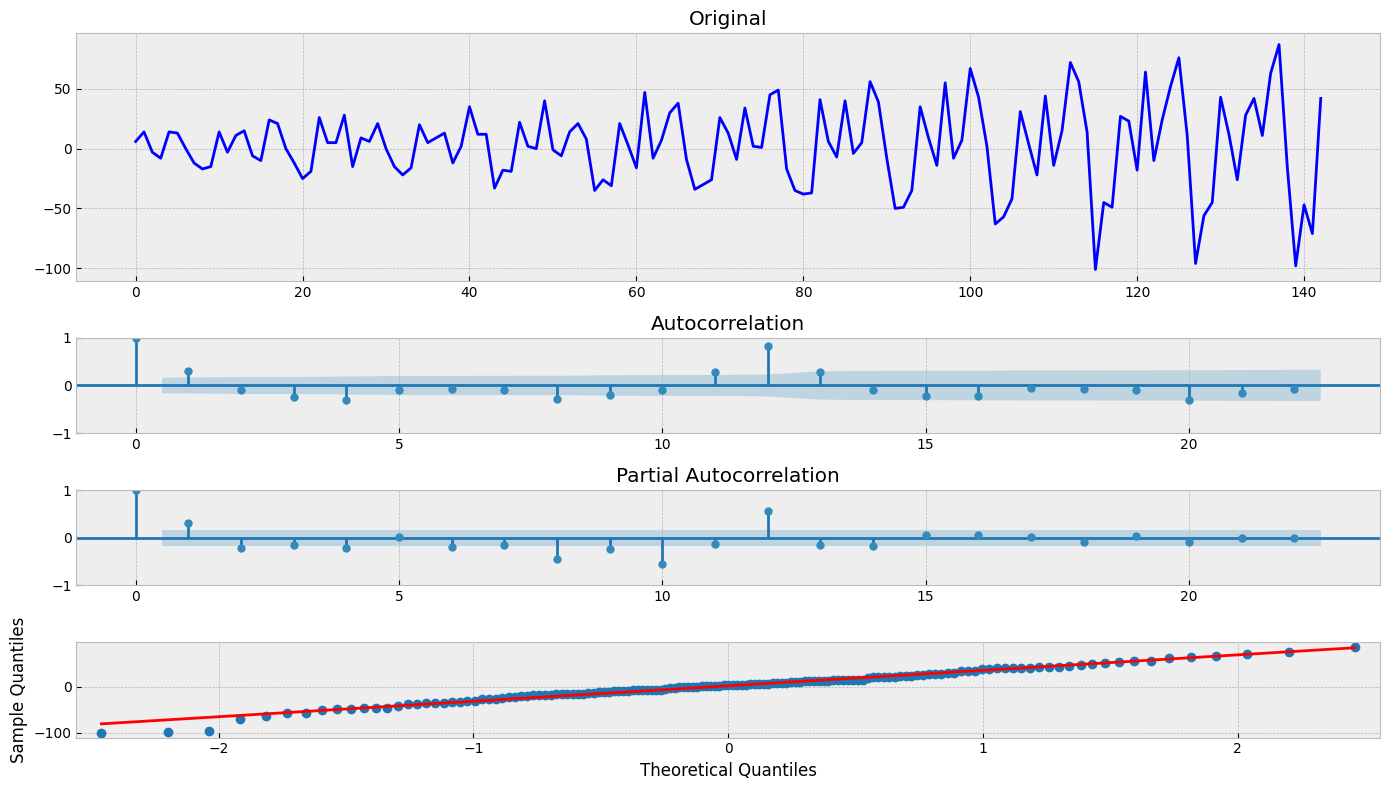

In [256]:
series_diff = np.diff(series, 1) # продифференцируем 1 раз и проверим снова

tsplot(series_diff)

В нашем случае, скорее всего:
* p = 12
* q = 12
* d = 1

# Модель ARIMA

In [220]:
best_aic = np.inf 
best_order = None
best_mdl = None

for p in range(13):
    for d in range(1, 2):
        for q in range(13):
            try:
                tmp_model = ARIMA(series, order=(p, d, q)).fit()

                tmp_aic = tmp_model.aic

                print(f"Order: {(p, d, q)} | AIC: {tmp_aic}")
                
                if tmp_aic < best_aic:
                    best_aic = tmp_aic
                    best_order = (p, d, q)
                    best_mdl = tmp_model
            except: continue

Order: (0, 1, 0) | AIC: 1413.9091174789412
Order: (0, 1, 1) | AIC: 1397.2575749491893
Order: (0, 1, 2) | AIC: 1397.093462089221
Order: (0, 1, 3) | AIC: 1394.9091477944332
Order: (0, 1, 4) | AIC: 1371.8500101175382
Order: (0, 1, 5) | AIC: 1373.7413859196079
Order: (0, 1, 6) | AIC: 1358.2715254315453
Order: (0, 1, 7) | AIC: 1345.162349409607
Order: (0, 1, 8) | AIC: 1334.519006194433
Order: (0, 1, 9) | AIC: 1330.1818644623331
Order: (0, 1, 10) | AIC: 1320.5735765716502
Order: (0, 1, 11) | AIC: 1352.8923315021088
Order: (0, 1, 12) | AIC: 1301.4512217190625
Order: (1, 1, 0) | AIC: 1401.8521274897143
Order: (1, 1, 1) | AIC: 1394.68250532513
Order: (1, 1, 2) | AIC: 1385.497545028962
Order: (1, 1, 3) | AIC: 1386.892207264969
Order: (1, 1, 4) | AIC: 1373.7887745107068
Order: (1, 1, 5) | AIC: 1353.6326705114182
Order: (1, 1, 6) | AIC: 1353.9953338040418
Order: (1, 1, 7) | AIC: 1331.8642555824433
Order: (1, 1, 8) | AIC: 1337.5864924192733
Order: (1, 1, 9) | AIC: 1337.6691352190635
Order: (1, 1, 1

Лучший (p, d, q): (12, 1, 3) | AIC: 1143.5919763975116
По тесту Дикки-Фуллера временной ряд стационарен: True


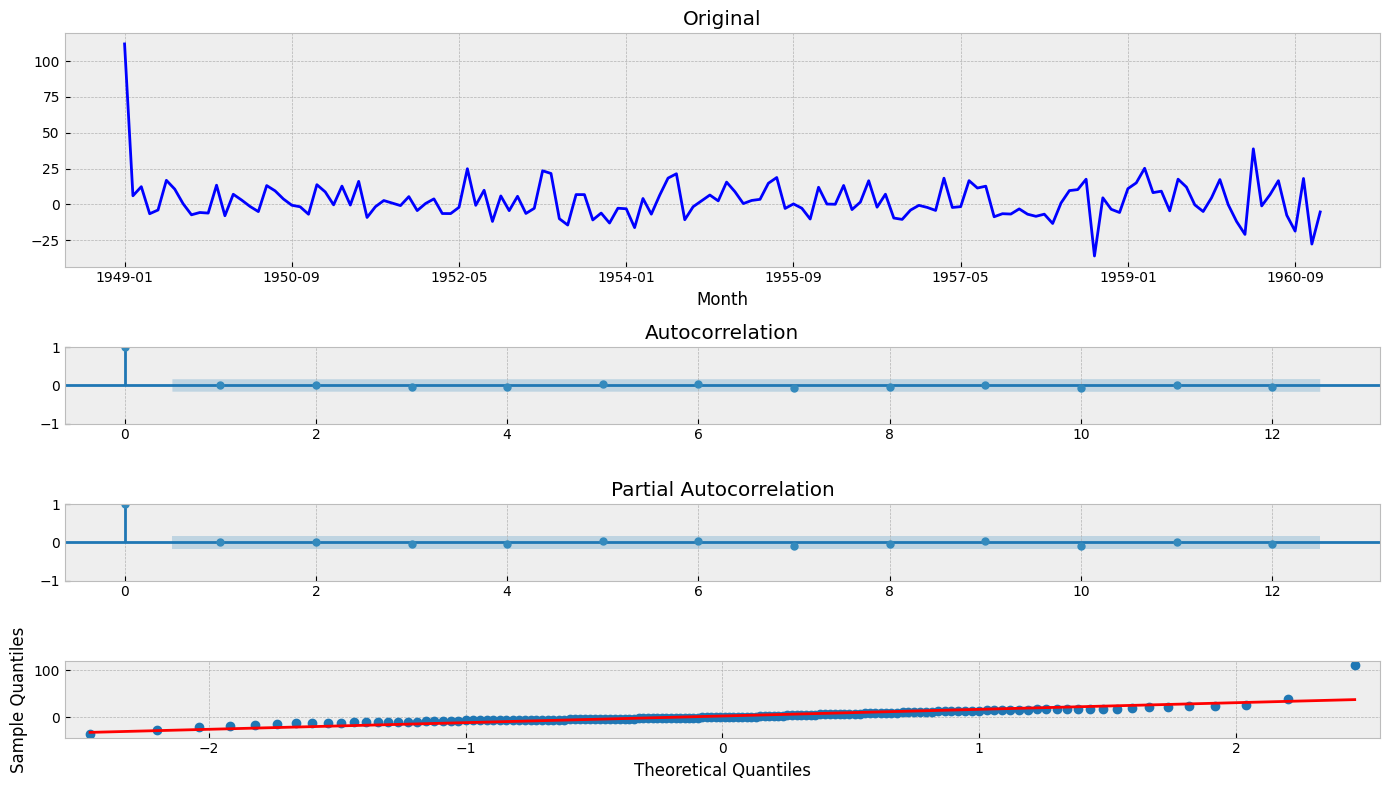

In [258]:
print(f"Лучший (p, d, q): {best_order} | AIC: {best_aic}")

tsplot(best_mdl.resid, lags=12)

Модель отлично справилась, так как остатки модели (белый шум) стационарные. Если остатки нестационарны, значит модель не учла какие-то паттерны.

## Тестирование модели

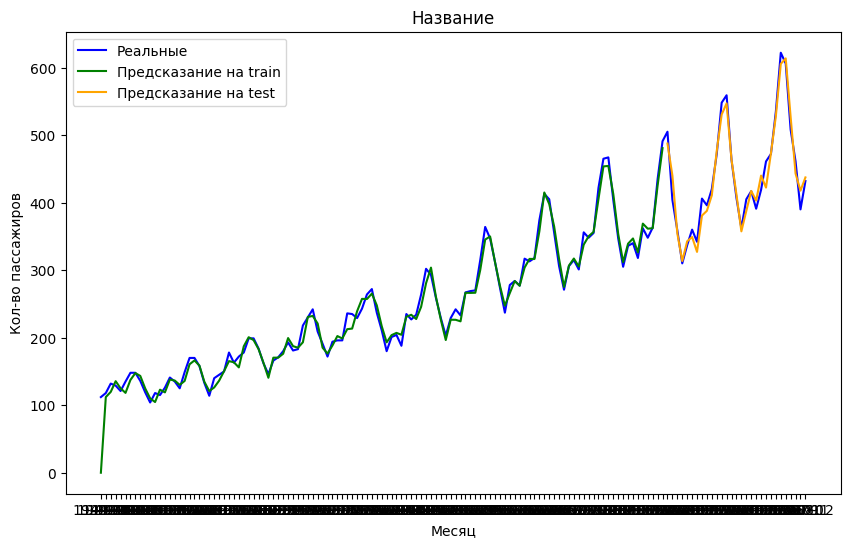

In [261]:
pred = best_mdl.predict(series.index[0], series.index[-1])

train_size = int(len(series) * 0.8)

train_predictions, test_predictions  = pred[:train_size], pred[train_size:]

plt.figure(figsize=(10, 6))

# Фактические данные
plt.plot(series.index, series, label='Реальные', color='blue')

# Обучающие предсказания
train_pred_index = series.index[:len(train_predictions)]
plt.plot(train_pred_index, train_predictions, label='Предсказание на train', color='green')

# Тестовые предсказания (если есть)
if len(test_predictions) > 0:
    test_pred_index = series.index[-len(test_predictions):]  # Берём последние точки
    plt.plot(test_pred_index, test_predictions, label='Предсказание на test', color='orange')

plt.title('Название')
plt.xlabel('Месяц')
plt.ylabel('Кол-во пассажиров')
plt.legend()
plt.show()

In [262]:
rmse = root_mean_squared_error(series[train_size:], test_predictions)

print("RMSE:", rmse)

RMSE: 16.145860823166135


## Предсказание на будущее

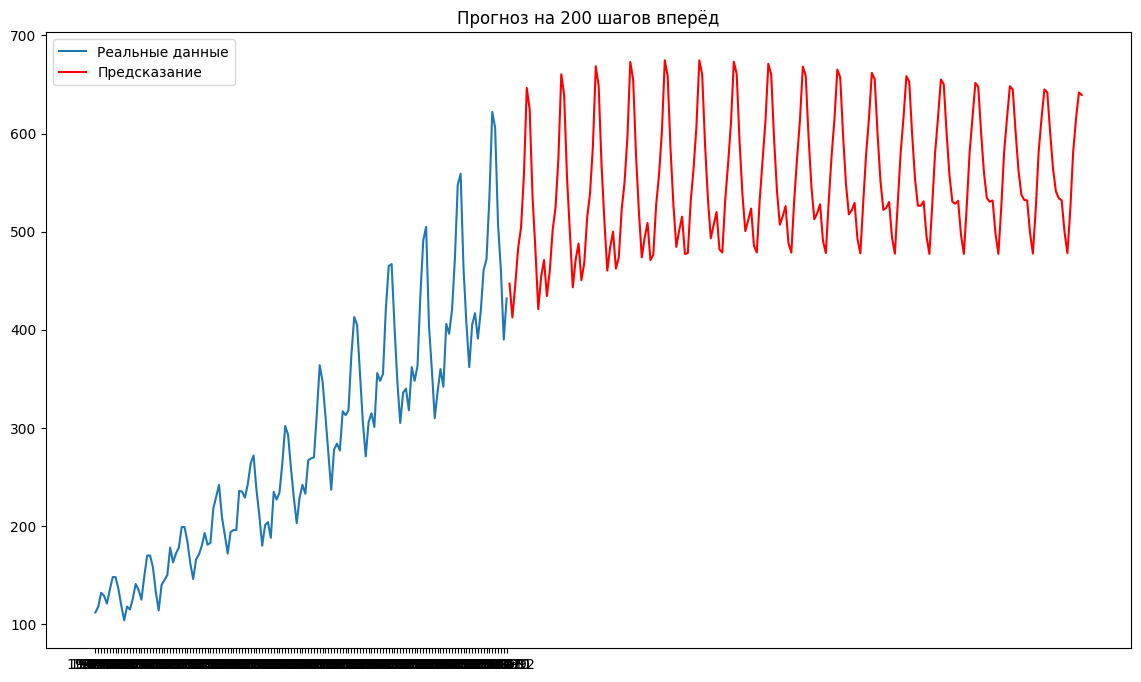

In [ ]:
forecast_steps = 200 # Кол-во шагов для предсказания
forecast = best_mdl.forecast(steps=forecast_steps)
forecast_index = np.arange(len(series), len(series) + forecast_steps)

# Визуализация результатов
plt.figure(figsize=(14, 8))
plt.plot(series.index, series, label='Реальные данные')
plt.plot(forecast_index, forecast, label='Предсказание', color='red')
plt.title(f"Прогноз на {forecast_steps} шагов вперёд")
plt.legend()
plt.show()

## Вывод: 
Модель ARIMA показала лучший RMSE, так что она была использована для прогнозирования.

# LSTM

## Подготовка данных

In [225]:
scaler = StandardScaler()

scaled_series = scaler.fit_transform(series.values.reshape(-1, 1)).reshape(-1)

pickle.dump(scaler, open("Scaler_TS.sav", "wb"))

Стандартизация данные позволяет модели нейронной сети обучаться более стабильно и быстро.

In [226]:
train_size = int(len(scaled_series) * 0.8)
test_size = len(scaled_series) - train_size
train, test = scaled_series[0:train_size], scaled_series[train_size:len(scaled_series)]

print(len(train), len(test))

115 29


In [227]:
# Функция для создания датасета
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

In [228]:
time_steps = 12 # Кол-во шагов назад, как призаки для предсказания

X_train, y_train = create_dataset(train, train, time_steps)
X_test, y_test = create_dataset(test, test, time_steps)

print(X_train.shape, y_train.shape)

(103, 12) (103,)


In [229]:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

## Построение модели

In [265]:
model = Sequential()

model.add(LSTM(
  units=128,
  input_shape=(1, X_train.shape[2]),
  activation="relu",
  return_sequences=True
))
model.add(LSTM(
  units=128,
  activation="relu"
))
model.add(Dense(units=1))

model.compile(
  loss='mean_squared_error',
  optimizer=Adam(0.01)
)

model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_20 (LSTM)              (None, 1, 128)            72192     
                                                                 
 lstm_21 (LSTM)              (None, 128)               131584    
                                                                 
 dense_13 (Dense)            (None, 1)                 129       
                                                                 
Total params: 203,905
Trainable params: 203,905
Non-trainable params: 0
_________________________________________________________________


Эта модель используется для анализа временных рядов с помощью рекуррентной нейронной сети (RNN), построенной на базе LSTM (Long Short-Term Memory). LSTM хорошо справляется с задачами, где важен контекст из предыдущих значений, например, при прогнозировании числовых данных во времени.

Используется архитектура Sequential, так как она позволяет строить модель поэтапно, слой за слоем. Первый слой LSTM с 128 нейронами получает входные данные с одним временным шагом и определённым числом признаков. Параметр return_sequences=True позволяет вернуть не только последнее значение, а всю последовательность, чтобы передать её следующему LSTM-слою.

Второй слой LSTM также содержит 128 нейронов, но уже возвращает только последнее значение последовательности — это итоговое представление, которое поступает на выходной полносвязный слой (Dense). Выходной слой выдаёт одно числовое значение — прогноз на основе входной последовательности.

Активация relu используется для ускорения обучения, хотя чаще в LSTM применяется tanh — это может быть экспериментальный выбор для улучшения результатов. Модель компилируется с функцией потерь mean_squared_error — стандартной для регрессии, и оптимизатором Adam с шагом обучения 0.01, который хорошо работает с LSTM.

Такая архитектура позволяет извлекать временные зависимости и делать точные прогнозы на основе предыдущих наблюдений.

In [267]:
checkpoint_path = "LSTM_Model.h5" # Путь до файла для сохранения модели
cp_callback = ModelCheckpoint(filepath=checkpoint_path, verbose=1) # Сохранение модели
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True) # Остановка обучения, если loss не уменьшается в течение 8 эпох

## Обучение модели

In [268]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False,
    callbacks=[early_stopping, cp_callback]
)

Epoch 1/100
1/3 [=========>....................] - ETA: 2s - loss: 0.9951
Epoch 1: saving model to LSTM_Model.h5
3/3 [==============================] - 2s 141ms/step - loss: 0.5701 - val_loss: 0.7472
Epoch 2/100
1/3 [=========>....................] - ETA: 0s - loss: 0.6830
Epoch 2: saving model to LSTM_Model.h5
3/3 [==============================] - 0s 32ms/step - loss: 0.4294 - val_loss: 0.6372
Epoch 3/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0981
Epoch 3: saving model to LSTM_Model.h5
3/3 [==============================] - 0s 31ms/step - loss: 0.1796 - val_loss: 0.3666
Epoch 4/100
1/3 [=========>....................] - ETA: 0s - loss: 2.4626
Epoch 4: saving model to LSTM_Model.h5
3/3 [==============================] - 0s 33ms/step - loss: 0.9676 - val_loss: 0.2949
Epoch 5/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0248
Epoch 5: saving model to LSTM_Model.h5
3/3 [==============================] - 0s 29ms/step - loss: 0.0896 - val_loss: 2.2298
Epoc

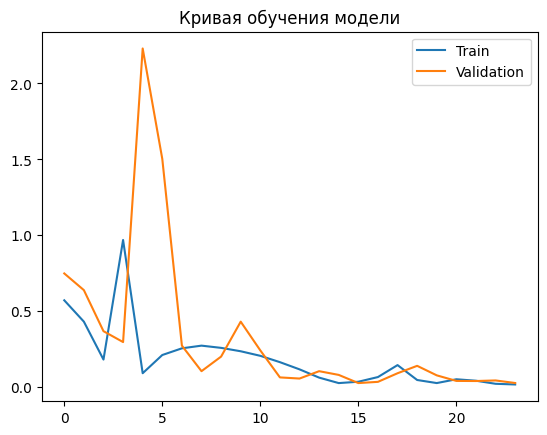

In [269]:
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Кривая обучения модели")
plt.legend()
plt.show()

## Тестирование модели

1/1 [==============================] - 0s 14ms/step


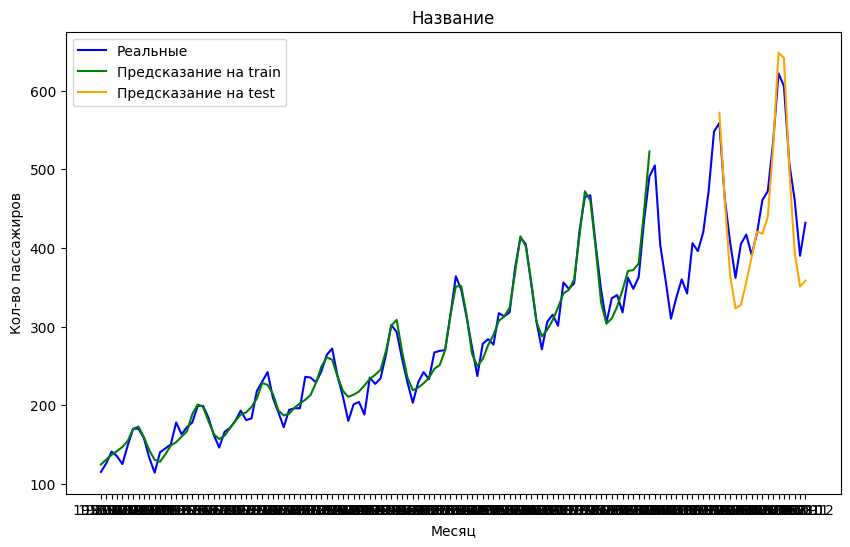

In [ ]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Inverse transform для возвращения масштаба
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)

plt.figure(figsize=(10, 6))

# Фактические данные
plt.plot(series.index[time_steps:], series[time_steps:], label='Реальные', color='blue')

# Обучающие предсказания
train_pred_index = series.index[time_steps : time_steps + len(train_predictions)]
plt.plot(train_pred_index, train_predictions, label='Предсказание на train', color='green')

# Тестовые предсказания (если есть)
if len(test_predictions) > 0:
    test_pred_index = series.index[-len(test_predictions):]  # Берём последние точки
    plt.plot(test_pred_index, test_predictions, label='Предсказание на test', color='orange')

plt.title('Название')
plt.xlabel('Месяц')
plt.ylabel('Кол-во пассажиров')
plt.legend()
plt.show()

In [235]:
unscaled_y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = root_mean_squared_error(unscaled_y_test, test_predictions)

print("RMSE: ", rmse)

RMSE:  41.6893932505099


## Предсказание на будущее

1/1 [==============================] - 0s 18ms/step


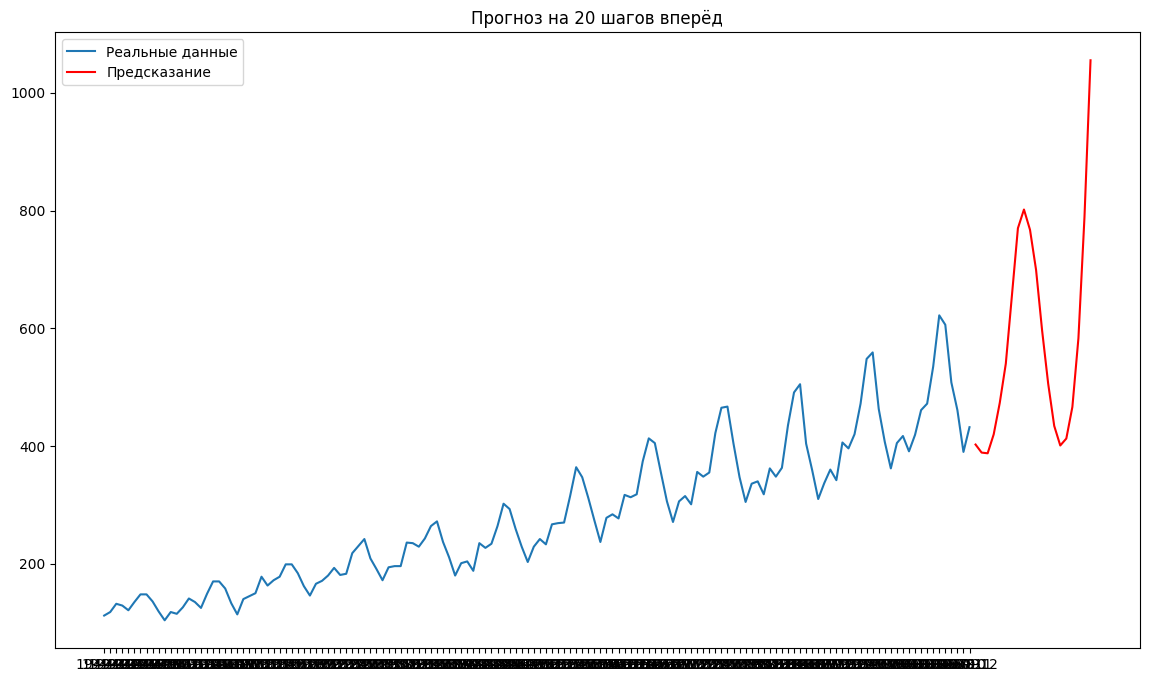

In [ ]:
forecast_steps = 20
last_sequence = X_test[-1:]  # Берём последнюю последовательность из тестовых данных
forecast = []

for _ in range(forecast_steps):
    # Предсказываем следующее значение
    next_value = model.predict(last_sequence)
    
    # Сохраняем предсказание
    forecast.append(next_value[0, 0])
    
    # Обновляем last_sequence: удаляем первый элемент и добавляем предсказание
    last_sequence = np.roll(last_sequence, shift=-1, axis=2)
    last_sequence[0, 0, -1] = next_value[0, 0]  # Вставляем новое значение в конец

# Преобразуем все предсказания обратно в исходный масштаб
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

forecast_index = np.arange(len(series), len(series) + forecast_steps)

# Визуализация
plt.figure(figsize=(14, 8))
plt.plot(series.index, series, label='Реальные данные')
plt.plot(forecast_index, forecast, label='Предсказание', color='red')
plt.title(f"Прогноз на {forecast_steps} шагов вперёд")
plt.legend()
plt.show()

## Вывод: 
Модель LSTM показала лучший RMSE, так что она была использована для прогнозирования.

# GRU

## Построение модели

In [237]:
model = Sequential()

model.add(GRU(
  units=128,
  input_shape=(1, X_train.shape[2]),
  activation="relu",
  return_sequences=True
))
model.add(GRU(
  units=128,
  activation="relu"
))
model.add(Dense(units=1))

model.compile(
  loss='mean_squared_error',
  optimizer=Adam(0.01)
)

model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_4 (GRU)                 (None, 1, 128)            54528     
                                                                 
 gru_5 (GRU)                 (None, 128)               99072     
                                                                 
 dense_12 (Dense)            (None, 1)                 129       
                                                                 
Total params: 153,729
Trainable params: 153,729
Non-trainable params: 0
_________________________________________________________________


GRU — это более лёгкая альтернатива LSTM, которая быстрее обучается и требует меньше вычислений, при этом тоже хорошо справляется с временными зависимостями.

Используется последовательная модель Sequential, позволяющая добавлять слои один за другим.

Первый слой GRU содержит 128 нейронов, принимает вход в виде одного временного шага и нескольких признаков (input_shape=(1, X_train.shape[2])). Параметр return_sequences=True нужен, чтобы вернуть всю последовательность и передать её второму GRU-слою. Активация relu используется для увеличения нелинейности и ускорения обучения, хотя обычно GRU использует tanh — это может быть выбрано экспериментально.

Второй слой GRU также содержит 128 нейронов, но уже возвращает только последнее значение, которое резюмирует всю последовательность. Это значение поступает на выходной слой Dense с одним нейроном, который выдаёт числовой прогноз.

Модель компилируется с функцией потерь mean_squared_error, стандартной для задач регрессии, и оптимизатором Adam с шагом обучения 0.01 — он обеспечивает быструю и стабильную сходимость.

Таким образом, модель извлекает временные зависимости из данных с помощью более компактной структуры GRU, что особенно полезно при большом объёме данных или ограниченных вычислительных ресурсах.

In [273]:
checkpoint_path = "GRU_Model.h5" # Путь до файла для сохранения модели
cp_callback = ModelCheckpoint(filepath=checkpoint_path,
                                                 verbose=1) # Сохранение модели
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True) # Остановка обучения, если loss не уменьшается в течение 8 эпох

## Обучение модели

In [239]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False,
    callbacks=[early_stopping, cp_callback]
)

Epoch 1/100
1/3 [=========>....................] - ETA: 3s - loss: 0.9576
Epoch 1: saving model to GRU_Model.h5
3/3 [==============================] - 2s 296ms/step - loss: 0.5596 - val_loss: 0.6862
Epoch 2/100
1/3 [=========>....................] - ETA: 0s - loss: 0.1811
Epoch 2: saving model to GRU_Model.h5
3/3 [==============================] - 0s 29ms/step - loss: 0.1903 - val_loss: 0.2217
Epoch 3/100
1/3 [=========>....................] - ETA: 0s - loss: 0.3684
Epoch 3: saving model to GRU_Model.h5
3/3 [==============================] - 0s 29ms/step - loss: 0.2147 - val_loss: 0.4984
Epoch 4/100
1/3 [=========>....................] - ETA: 0s - loss: 0.1594
Epoch 4: saving model to GRU_Model.h5
3/3 [==============================] - 0s 26ms/step - loss: 0.1514 - val_loss: 1.1927
Epoch 5/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0350
Epoch 5: saving model to GRU_Model.h5
3/3 [==============================] - 0s 27ms/step - loss: 0.0693 - val_loss: 0.1684
Epoch 6/1

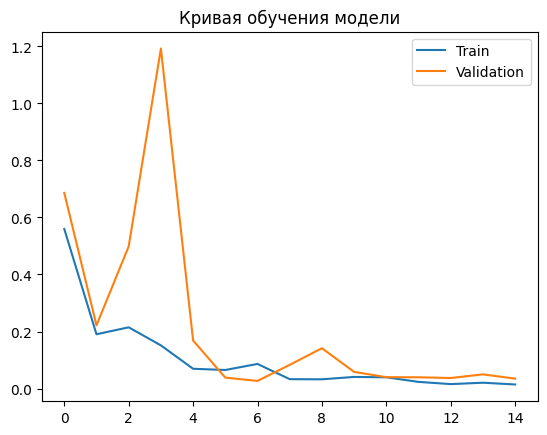

In [240]:
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Кривая обучения модели")
plt.legend()
plt.show()

## Тестирование модели

1/1 [==============================] - 0s 12ms/step


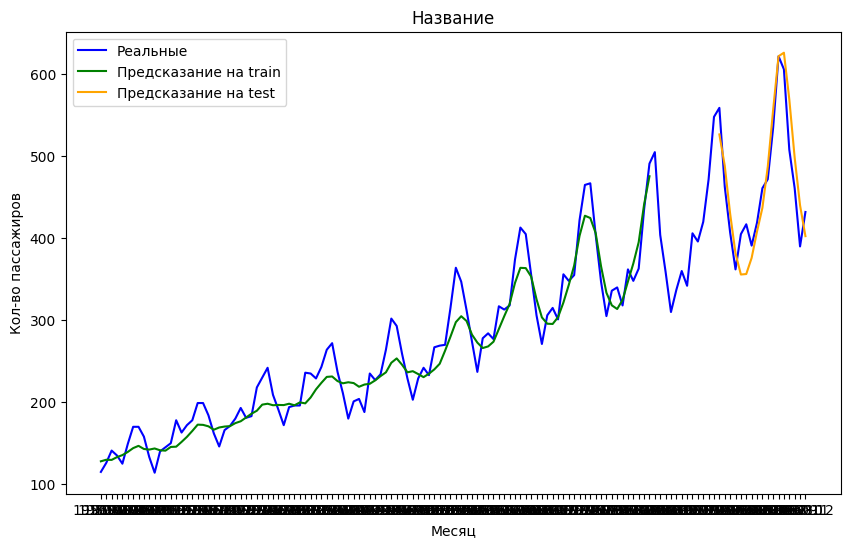

In [ ]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Inverse transform для возвращения масштаба
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)

plt.figure(figsize=(10, 6))

# Фактические данные
plt.plot(series.index[time_steps:], series[time_steps:], label='Реальные', color='blue')

# Обучающие предсказания
train_pred_index = series.index[time_steps : time_steps + len(train_predictions)]
plt.plot(train_pred_index, train_predictions, label='Предсказание на train', color='green')

# Тестовые предсказания (если есть)
if len(test_predictions) > 0:
    test_pred_index = series.index[-len(test_predictions):]  # Берём последние точки
    plt.plot(test_pred_index, test_predictions, label='Предсказание на test', color='orange')

plt.title('Название')
plt.xlabel('Месяц')
plt.ylabel('Кол-во пассажиров')
plt.legend()
plt.show()

In [242]:
unscaled_y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = root_mean_squared_error(unscaled_y_test, test_predictions)

print("RMSE: ", rmse)

RMSE:  33.70607544558027


## Предсказание на будущее

1/1 [==============================] - 0s 14ms/step


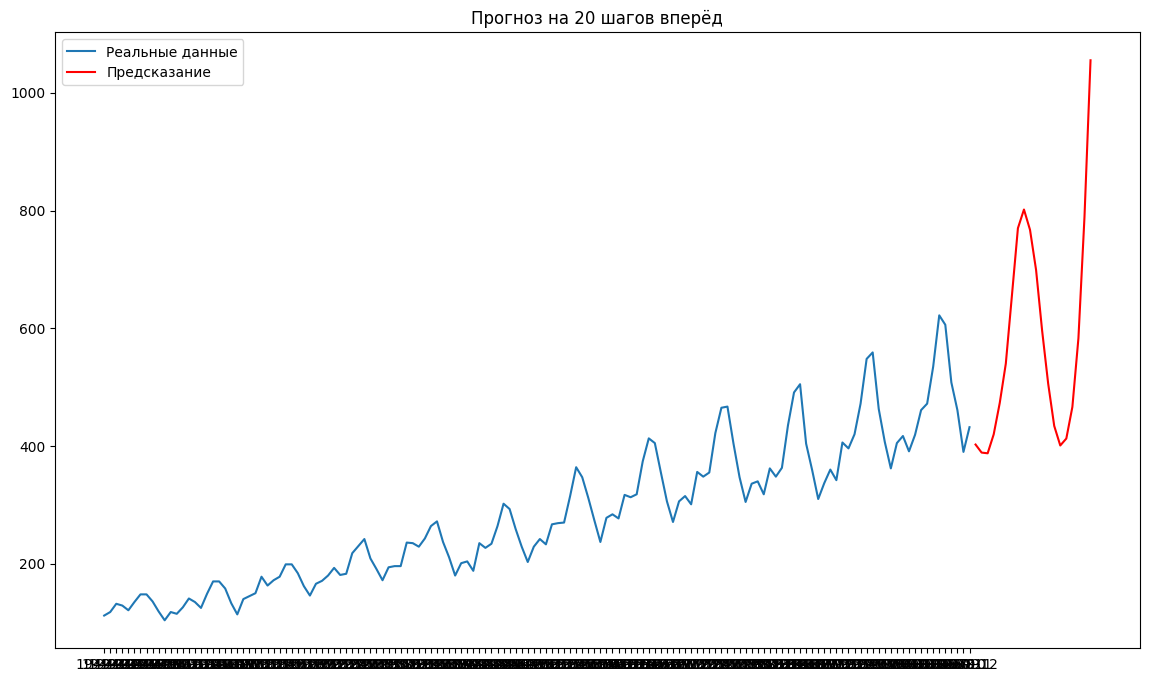

In [ ]:
forecast_steps = 20
last_sequence = X_test[-1:]  # Берём последнюю последовательность из тестовых данных
forecast = []

for _ in range(forecast_steps):
    # Предсказываем следующее значение
    next_value = model.predict(last_sequence)
    
    # Сохраняем предсказание
    forecast.append(next_value[0, 0])
    
    # Обновляем last_sequence: удаляем первый элемент и добавляем предсказание
    last_sequence = np.roll(last_sequence, shift=-1, axis=2)
    last_sequence[0, 0, -1] = next_value[0, 0]  # Вставляем новое значение в конец

# Преобразуем все предсказания обратно в исходный масштаб
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

forecast_index = np.arange(len(series), len(series) + forecast_steps)

# Визуализация
plt.figure(figsize=(14, 8))
plt.plot(series.index, series, label='Реальные данные')
plt.plot(forecast_index, forecast, label='Предсказание', color='red')
plt.title(f"Прогноз на {forecast_steps} шагов вперёд")
plt.legend()
plt.show()

## Вывод: 
Модель GRU показала лучший RMSE, так что она была использована для прогнозирования.